# Customer Order Analysis

In [1]:
import pymysql
import pandas as pd

## Database Connection

In this step, a connection to the ClassicModels database is established using PyMySQL.

In [2]:
conn = pymysql.connect(
    host="localhost",
    user="nhy",
    password="Hoangyen9626!",
    database="classicmodels"
)

## Load Customer Data

Retrieve customer number and customer name from the customers table.

In [3]:
customers = pd.read_sql(
    "SELECT customerNumber, customerName FROM customers",
    conn
)

customers.head()

/var/folders/v6/s8fq5ntn2ms_7tyvk6l48qf00000gn/T/ipykernel_72505/157101169.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql(


,customerNumber,customerName
0,103,Atelier graphique
1,112,Signal Gift Stores
2,114,"Australian Collectors, Co."
3,119,La Rochelle Gifts
4,121,Baane Mini Imports


### Dataset Inspection

The following checks are performed:

- Number of rows and columns
- Data types
- Summary statistics

In [4]:
customers.shape

(123, 2)

In [5]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customerNumber  123 non-null    int64
 1   customerName    123 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.1 KB


## Load Orders Data

In [6]:
orders = pd.read_sql(
    """
    SELECT orderNumber,
           customerNumber,
           orderDate,
           status
    FROM orders
    """,
    conn
)

orders.head()

/var/folders/v6/s8fq5ntn2ms_7tyvk6l48qf00000gn/T/ipykernel_72505/1554121631.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql(


,orderNumber,customerNumber,orderDate,status
0,10100,363,2003-01-06,Shipped
1,10101,128,2003-01-09,Shipped
2,10102,181,2003-01-10,Shipped
3,10103,121,2003-01-29,Shipped
4,10104,141,2003-01-31,Shipped


## Merge Customers and Orders

An inner join is performed using customerNumber as the common key.

In [7]:
df = pd.merge(
    customers,
    orders,
    on="customerNumber",
    how="inner"
)

df.head()

,customerNumber,customerName,orderNumber,orderDate,status
0,103,Atelier graphique,10123,2003-05-20,Shipped
1,103,Atelier graphique,10298,2004-09-27,Shipped
2,103,Atelier graphique,10345,2004-11-25,Shipped
3,112,Signal Gift Stores,10124,2003-05-21,Shipped
4,112,Signal Gift Stores,10278,2004-08-06,Shipped


## Data Analysis

This section explores the merged dataset.

In [8]:
df["status"].value_counts()

status
Shipped       303
In Process      6
Cancelled       6
Resolved        4
On Hold         4
Disputed        3
Name: count, dtype: int64

## Visualization

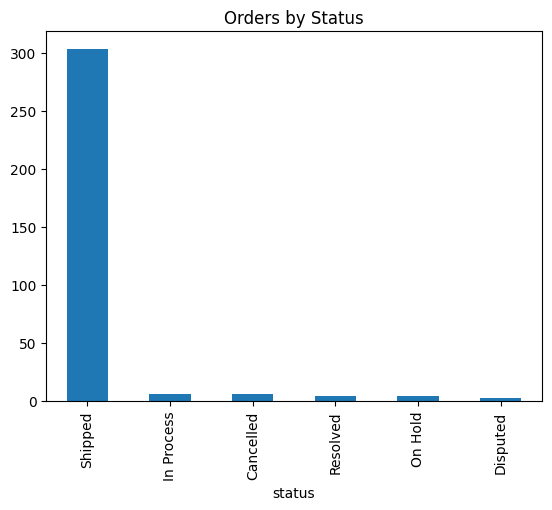

In [9]:
import matplotlib.pyplot as plt

df["status"].value_counts().plot(kind="bar")
plt.title("Orders by Status")
plt.show()

## Export Result

Export the first five records to a tab-separated text file.

In [10]:
df = df.sort_values(
    by="orderNumber"
).head(5)

df.to_csv(
    "jupyter_customer_orders.txt",
    sep="\t",
    index=False
)

## Conclusion

Key observations